# DPDM Project
(MBA DS&DA 24-26)

Objective:
# Extract Historical Sensex Data and Visualize How Major Events can effect the Market 


Group Members
1. Anubhav Sarkar(24030242010) : Data Extraction, Cleaning, Pre-Processing
2. Anik Basu(24030242006) : Data Extraction, Cleaning, Pre-Processing
3. Palak Ghorpade(24030242079) : Analysis, Visualisation
4. Sreeja Roy(24030242066) : Analysis, Visualisation

# Data Extraction
Source: BSE India Website;
Extracted data: BSE SENSEX, BSE 500 (Historical data);
Tool: Selenium;

Step 1: Import the necessary Libraries and Setup the Web driver Service

In [39]:
####Importing Libraries####
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import Select
from selenium.webdriver.common.by import By
from selenium.webdriver.support import expected_conditions as EC
import time
import pandas as pd
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

In [2]:
#Setup Web Driver Service#
service = Service("E:/chromedriver-win64/chromedriver-win64/chromedriver.exe")

Step 2: Build a Automated Test Software to access the Website and Gather the Required Data

(Period: Daily) 

In [53]:
driver = webdriver.Chrome(service=service)
driver.get("https://www.bseindia.com/Indices/IndexArchiveData.html")

#### Index ####
dropdown_element = driver.find_element(By.ID, "ddlIndex")
index_dropdown = Select(dropdown_element)
index_dropdown.select_by_visible_text("All Indices")

#### Period ####(Set to Daily only)
period_dropdown = Select(driver.find_element(By.ID, "ddlPeriodtype"))
period_dropdown.select_by_visible_text("Daily")

#### from date ####
dfrom = driver.find_element(By.ID, "txtFromDt")
dfrom.click()
yeardd = driver.find_element(By.CLASS_NAME, "ui-datepicker-year")
yearopt = Select(yeardd)
yearopt.select_by_visible_text("2023")#year
monthdd = driver.find_element(By.CLASS_NAME, "ui-datepicker-month")
monthopt = Select(monthdd)
monthopt.select_by_visible_text("Nov") #Enter first 3 letters of the month (January-->Jan)#


driver.find_element(By.XPATH, "//a[text()='3']").click()

#### to date ####(only if needed data for a particular INDEX)
dto = driver.find_element(By.ID, "txtToDt")
dto.click()
monthdd2 = driver.find_element(By.CLASS_NAME, "ui-datepicker-month")
monthopt2 = Select(monthdd2)
monthopt2.select_by_visible_text("May") #Enter first 3 letters of the month (January-->Jan)#
yeardd2 = driver.find_element(By.CLASS_NAME, "ui-datepicker-year")
yearopt2 = Select(yeardd2)
yearopt2.select_by_visible_text("2014") #year

#date Should be same if Indices are set to 'All Indices'
driver.find_element(By.XPATH, "//a[text()='20']").click() #date

#### Submit ####
driver.find_element(By.XPATH, "//input[@value='Submit']").click()

#### Table Extraction ####
time.sleep(5)

table = driver.find_element(By.XPATH, '//*[@id="divmain"]/div[3]/div[3]/div[1]/table/tbody/tr/td/table')

headers = []
header_row = table.find_element(By.TAG_NAME, "tr")
header_cells = header_row.find_elements(By.TAG_NAME, "th")
for header_cell in header_cells:
    headers.append(header_cell.text)

rows = table.find_elements(By.TAG_NAME, "tr")[:]

table_data = []

for row in rows:
    cells = row.find_elements(By.TAG_NAME, "td")
    row_data = {}
    for idx, cell in enumerate(cells):
        row_data[idx + 1] = cell.text
    table_data.append(row_data)

###Making Sure Data is Captured###
for entry in table_data:
    print(entry)

headers = list(table_data[0].values())
data = [list(entry.values()) for entry in table_data[1:]]

# Create a Temporary DataFrame
table1 = pd.DataFrame(data, columns=headers)

if table1.empty:
    print("The table is empty, assuming the date is a weekend.")
else:
    print("Data Captured!")

####QUIT####
driver.quit()

{1: 'Date', 2: 'Index Name', 3: 'Open', 4: 'High', 5: 'Low', 6: 'Close', 7: 'Points Change', 8: 'Change(%)', 9: 'Volume', 10: 'Turnover (Rs.Cr.)', 11: 'P/E', 12: 'P/B', 13: 'Div Yield'}
{1: '03/11/2023', 2: 'BSE 100', 3: '19,757.34', 4: '19,798.82', 5: '19,733.83', 6: '19,760.37', 7: '117.38', 8: '0.60', 9: '4.22', 10: '2,085.29', 11: '22.21', 12: '3.34', 13: '1.35'}
{1: '03/11/2023', 2: 'BSE 100 ESG Index', 3: '316.18', 4: '316.74', 5: '315.51', 6: '315.85', 7: '1.47', 8: '0.47', 9: '2.48', 10: '1,453.48', 11: '21.63', 12: '3.01', 13: '1.28'}
{1: '03/11/2023', 2: 'BSE 100 LargeCap TMC Index', 3: '6,993.17', 4: '7,009.01', 5: '6,985.24', 6: '6,994.63', 7: '41.65', 8: '0.60', 9: '4.39', 10: '2,071.52', 11: '21.91', 12: '3.31', 13: '1.38'}
{1: '03/11/2023', 2: 'BSE 150 MidCap Index', 3: '11,060.97', 4: '11,079.05', 5: '11,035.18', 6: '11,068.06', 7: '73.59', 8: '0.67', 9: '20.11', 10: '956.71', 11: '27.07', 12: '3.37', 13: '0.99'}
{1: '03/11/2023', 2: 'BSE 200', 3: '8,443.82', 4: '8,460.

(Period: Monthly)

In [53]:
driver = webdriver.Chrome(service=service)
driver.get("https://www.bseindia.com/Indices/IndexArchiveData.html")

dropdown_element = driver.find_element(By.ID, "ddlIndex")
index_dropdown = Select(dropdown_element)
index_dropdown.select_by_visible_text("BSE SENSEX")

period_dropdown = Select(driver.find_element(By.ID, "ddlPeriodtype"))
period_dropdown.select_by_visible_text("Monthly")


driver.find_element(By.XPATH, '//*[@id="divmain"]/div[2]/div[3]/div[2]/select/option[5]').click()


driver.find_element(By.XPATH, '//*[@id="divmain"]/div[2]/div[3]/div[3]/select/option[7]').click()

driver.find_element(By.XPATH, "//input[@value='Submit']").click()

time.sleep(5)

# Locate the table element
table = driver.find_element(By.XPATH, '//*[@id="divmain"]/div[3]/div[3]/div[1]/table/tbody/tr/td/table')

headers = []
header_row = table.find_element(By.TAG_NAME, "tr")
header_cells = header_row.find_elements(By.TAG_NAME, "th")
for header_cell in header_cells:
    headers.append(header_cell.text)

# Extract the remaining rows
rows = table.find_elements(By.TAG_NAME, "tr")[:]  

# List to hold dictionaries
table_data = []

# Loop through rows and extract data
for row in rows:
    cells = row.find_elements(By.TAG_NAME, "td")
    row_data = {}
    for idx, cell in enumerate(cells):
        row_data[idx + 1] = cell.text
    table_data.append(row_data)



headers = list(table_data[0].values())
data = [list(entry.values()) for entry in table_data[1:]]

first_row_data = [data[0]]  # Wrapping in a list to maintain 2D structure
temp_table = pd.DataFrame(first_row_data, columns=headers)

print(temp_table)
# Close the browser
driver.quit()

    Month       Open       High        Low      Close
0  Apr 19  38,858.88  39,487.45  38,460.25  39,031.55


# BUILDING THE COMPLETE DATASET

In [397]:
bse_sensex_data = table1[table1['Index Name'] == 'BSE SENSEX']
bse_500_data = table1[table1['Index Name'] == 'BSE 500']

# Data for BSE SENSEX #
try:
    table_sensex = pd.read_csv('bse_sensex.csv')
except FileNotFoundError:
    table_sensex = pd.DataFrame(columns=table1.columns)

# Data for BSE 500 #
try:
    table_500 = pd.read_csv('bse_500.csv')
except FileNotFoundError:
    table_500 = pd.DataFrame(columns=table1.columns)

# Append the filtered data #
table_sensex = pd.concat([table_sensex, bse_sensex_data], ignore_index=True)
table_500 = pd.concat([table_500, bse_500_data], ignore_index=True)

# Save the updated DataFrames #
table_sensex.to_csv('bse_sensex.csv', index=False)
table_500.to_csv('bse_500.csv', index=False)

# Print the updated DataFrames to check the accumulated data
print("BSE SENSEX Data:")
print(table_sensex)

print("BSE 500 Data:")
print(table_500)


BSE SENSEX Data:
           Date  Index Name       Open       High        Low      Close  \
0    08-05-2014  BSE SENSEX  22,382.14  22,443.13  22,277.04  22,344.04   
1    09-05-2014  BSE SENSEX  22,374.98  23,048.49  22,317.18  22,994.23   
2    12-05-2014  BSE SENSEX  23,031.11  23,572.88  23,008.65  23,551.00   
3    13-05-2014  BSE SENSEX  23,729.78  24,068.94  23,729.25  23,871.23   
4    14-05-2014  BSE SENSEX  23,897.88  23,964.67  23,753.36  23,815.12   
..          ...         ...        ...        ...        ...        ...   
256  30/10/2023  BSE SENSEX  63,885.56  64,184.58  63,431.45  64,112.65   
257  31/10/2023  BSE SENSEX  64,449.65  64,452.32  63,812.53  63,874.93   
258  01/11/2023  BSE SENSEX  63,829.87  63,896.05  63,550.46  63,591.33   
259  02/11/2023  BSE SENSEX  64,033.40  64,202.64  63,815.35  64,080.90   
260  03/11/2023  BSE SENSEX  64,444.90  64,535.19  64,275.39  64,363.78   

    Points Change Change(%) Volume Turnover (Rs.Cr.)    P/E   P/B Div Yield  
0   

INCASE NEED TO CLEAR TABLE REMOVE THE # AND RUN THE CODE BELOW

In [398]:
#table2=pd.DataFrame(columns=table2.columns)
#print(table2)

# Cleaning And Pre Processing

In [3]:
#Sorting The Data From Oldest to Newest, Changing all The Date entries to one common format
data = pd.read_csv("E:/sel/bse_sensex.csv")

data['Date'] = pd.to_datetime(data['Date'], dayfirst=True, errors='coerce')

data = data.sort_values(by='Date', ascending=True)

print(data.head())

        Date  Index Name       Open       High        Low      Close  \
0 2014-05-08  BSE SENSEX  22,382.14  22,443.13  22,277.04  22,344.04   
1 2014-05-09  BSE SENSEX  22,374.98  23,048.49  22,317.18  22,994.23   
2 2014-05-12  BSE SENSEX  23,031.11  23,572.88  23,008.65  23,551.00   
3 2014-05-13  BSE SENSEX  23,729.78  24,068.94  23,729.25  23,871.23   
4 2014-05-14  BSE SENSEX  23,897.88  23,964.67  23,753.36  23,815.12   

  Points Change  Change(%) Volume Turnover (Rs.Cr.)    P/E   P/B  Div Yield  
0         20.14       0.09    0.6             366.9  17.41  2.64       1.48  
1        650.19       2.91   1.13            659.45  17.88  2.71       1.43  
2        556.77       2.42   1.24            796.71  18.22  2.78       1.42  
3        320.23       1.36   1.82            907.88  18.44  2.82       1.41  
4        -56.11      -0.24   1.15            628.64  18.52  2.83       1.40  


Converting all the Columns to Numeric for Easy Satistical Operations

In [27]:
cols_to_convert = ['Open', 'High', 'Low', 'Close', 'Points Change', 'Change(%)', 
                   'Volume', 'Turnover (Rs.Cr.)', 'P/E', 'P/B', 'Div Yield']

# Convert columns to numeric
for col in cols_to_convert:
    if data[col].dtype == 'object':  # Check if the column is of type object (usually strings)
        data[col] = pd.to_numeric(data[col].str.replace(',', ''), errors='coerce')
    else:
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Display the updated DataFrame
print(data.head())

         Date  Index Name      Open      High       Low     Close  \
0  08-05-2014  BSE SENSEX  22382.14  22443.13  22277.04  22344.04   
1  09-05-2014  BSE SENSEX  22374.98  23048.49  22317.18  22994.23   
2  12-05-2014  BSE SENSEX  23031.11  23572.88  23008.65  23551.00   
3  13-05-2014  BSE SENSEX  23729.78  24068.94  23729.25  23871.23   
4  14-05-2014  BSE SENSEX  23897.88  23964.67  23753.36  23815.12   

   Points Change  Change(%)  Volume  Turnover (Rs.Cr.)    P/E   P/B  Div Yield  
0          20.14       0.09    0.60             366.90  17.41  2.64       1.48  
1         650.19       2.91    1.13             659.45  17.88  2.71       1.43  
2         556.77       2.42    1.24             796.71  18.22  2.78       1.42  
3         320.23       1.36    1.82             907.88  18.44  2.82       1.41  
4         -56.11      -0.24    1.15             628.64  18.52  2.83       1.40  


# Missing value Detection and Imputation

In [28]:
# Check for missing values
missing_values = data.isnull().sum()

# Display missing values count for each column
print(missing_values)

# Display rows with missing values
rows_with_missing_values = data[data.isnull().any(axis=1)]

# Print the rows with missing values
print(rows_with_missing_values)


Date                 0
Index Name           0
Open                 0
High                 0
Low                  0
Close                0
Points Change        0
Change(%)            0
Volume               4
Turnover (Rs.Cr.)    4
P/E                  0
P/B                  0
Div Yield            0
dtype: int64
           Date  Index Name      Open      High       Low     Close  \
176  03-12-2020  BSE SENSEX  44902.02  44953.01  44551.42  44632.65   
185  16-12-2020  BSE SENSEX  46573.31  46704.97  46402.20  46666.46   
214  30-11-2021  BSE SENSEX  57272.08  58183.77  56867.51  57064.87   
220  21-02-2022  BSE SENSEX  57551.65  58141.96  57167.02  57683.59   

     Points Change  Change(%)  Volume  Turnover (Rs.Cr.)    P/E   P/B  \
176          14.61       0.03     NaN                NaN  31.71  2.95   
185         403.29       0.87     NaN                NaN  33.39  3.11   
214        -195.71      -0.34     NaN                NaN  26.75  3.49   
220        -149.38      -0.26     NaN   

# KNN Imputation 

In [29]:
knn_imputer = KNNImputer(n_neighbors=5)

# Perform KNN imputation on the selected columns
data[cols_to_convert] = knn_imputer.fit_transform(data[cols_to_convert])

# Display the first few rows of the updated data with imputed values
print(data.head())

missing_values = data.isnull().sum()
print(missing_values)


         Date  Index Name      Open      High       Low     Close  \
0  08-05-2014  BSE SENSEX  22382.14  22443.13  22277.04  22344.04   
1  09-05-2014  BSE SENSEX  22374.98  23048.49  22317.18  22994.23   
2  12-05-2014  BSE SENSEX  23031.11  23572.88  23008.65  23551.00   
3  13-05-2014  BSE SENSEX  23729.78  24068.94  23729.25  23871.23   
4  14-05-2014  BSE SENSEX  23897.88  23964.67  23753.36  23815.12   

   Points Change  Change(%)  Volume  Turnover (Rs.Cr.)    P/E   P/B  Div Yield  
0          20.14       0.09    0.60             366.90  17.41  2.64       1.48  
1         650.19       2.91    1.13             659.45  17.88  2.71       1.43  
2         556.77       2.42    1.24             796.71  18.22  2.78       1.42  
3         320.23       1.36    1.82             907.88  18.44  2.82       1.41  
4         -56.11      -0.24    1.15             628.64  18.52  2.83       1.40  
Date                 0
Index Name           0
Open                 0
High                 0
Low    

# Check Data Distribution

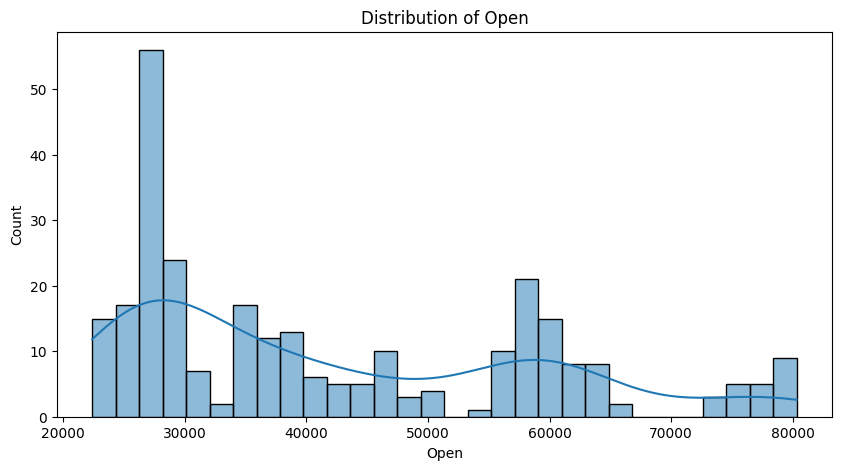

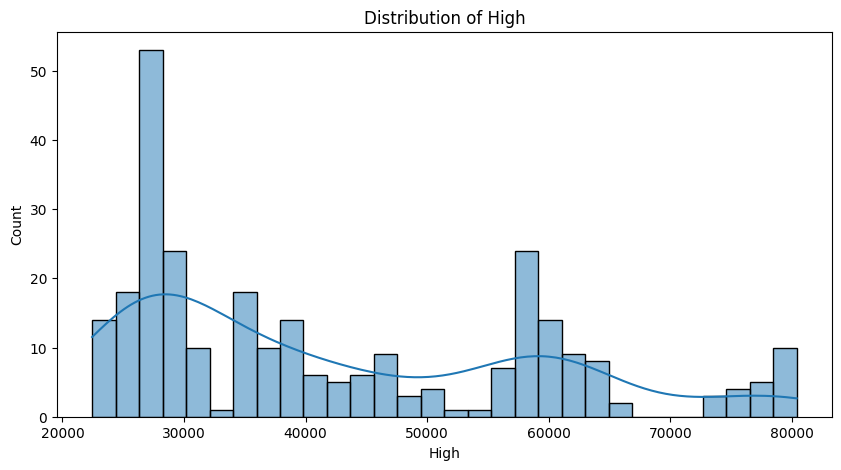

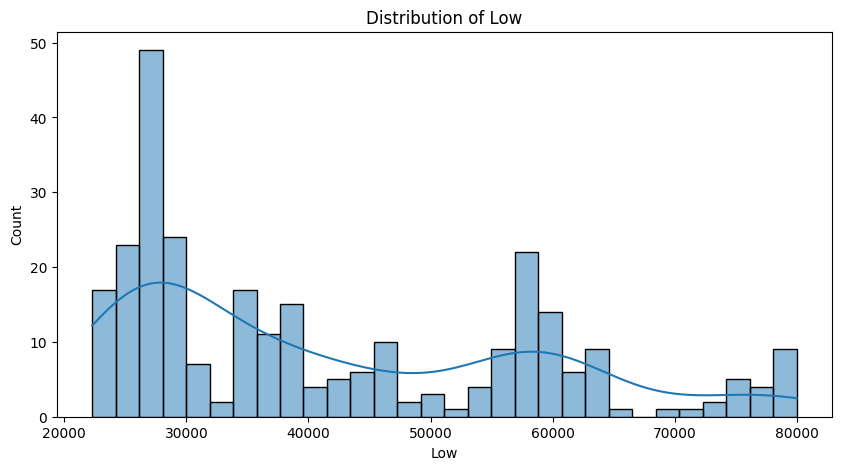

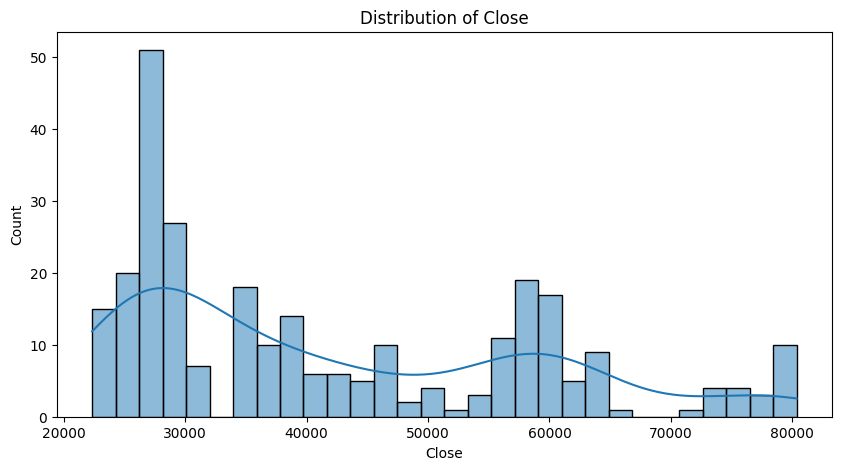

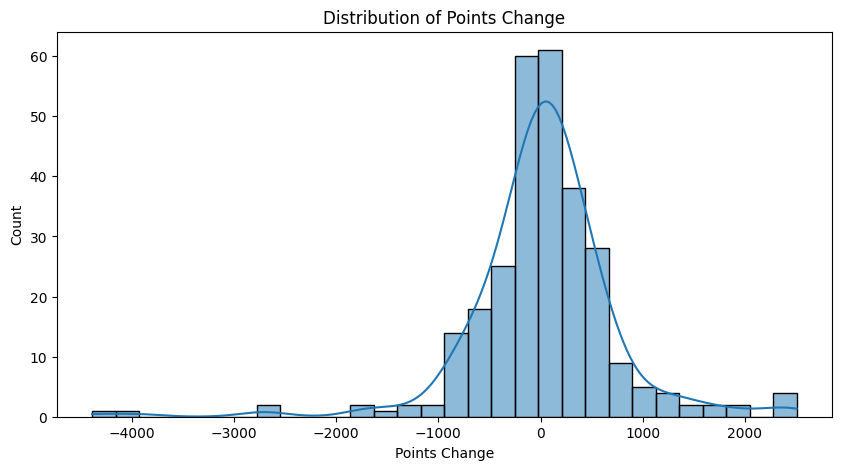

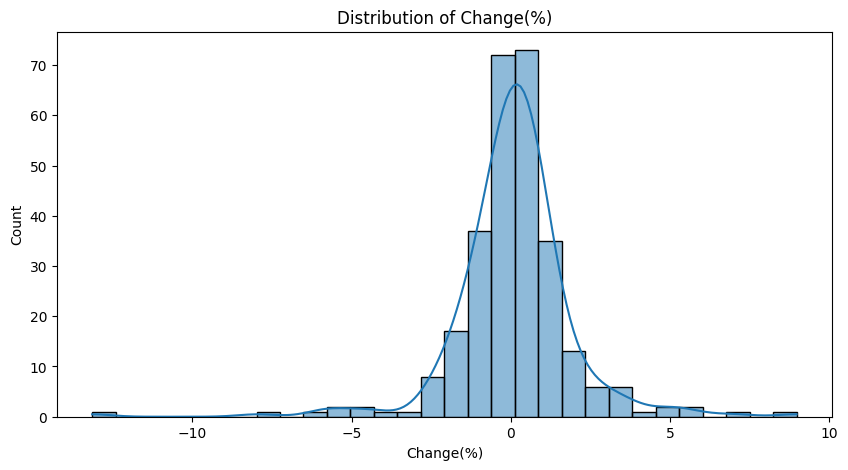

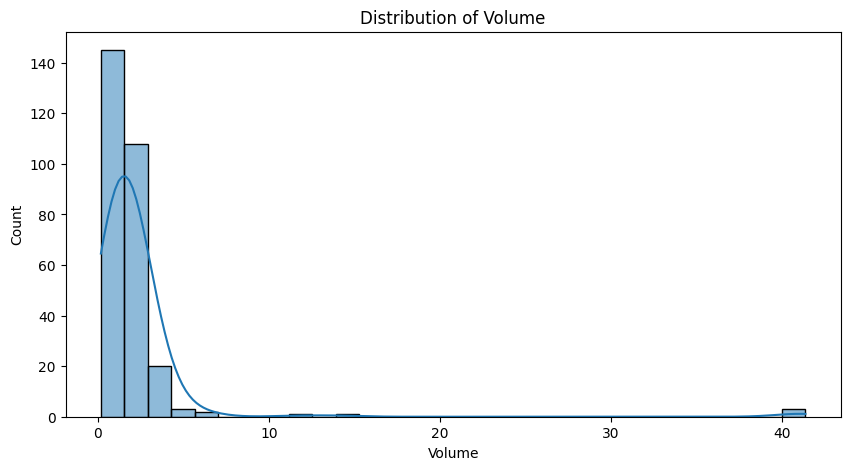

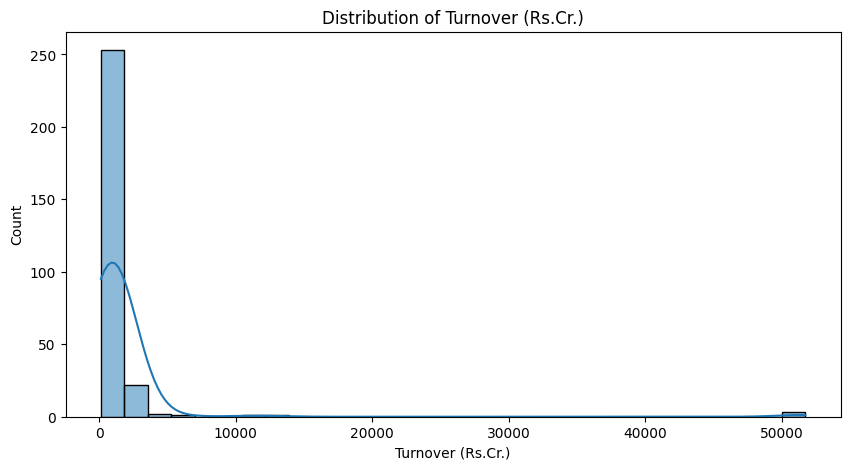

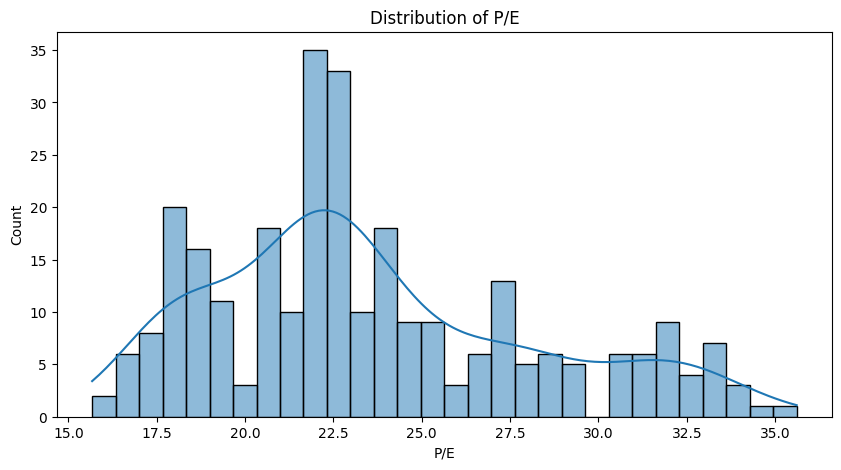

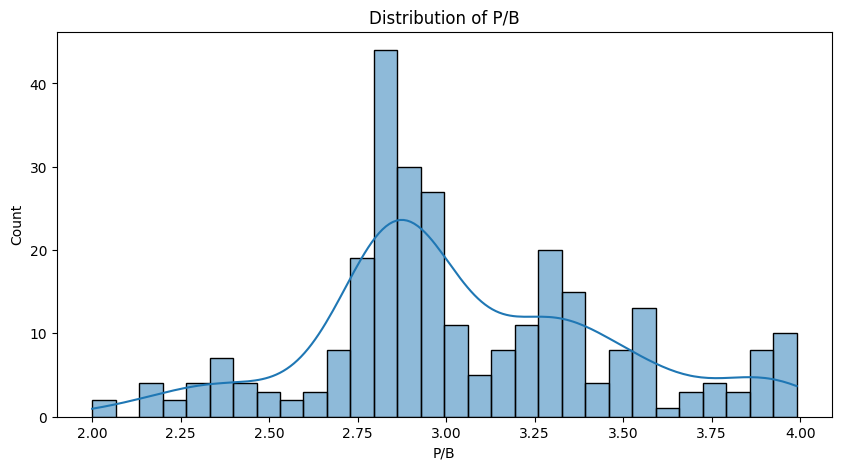

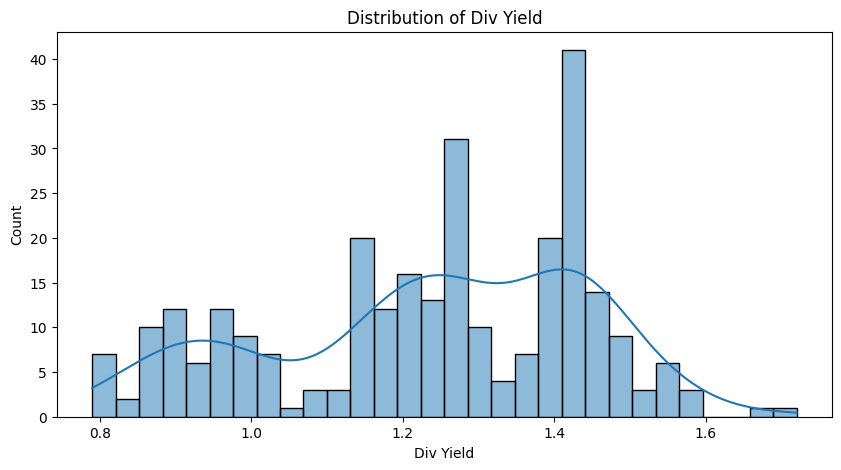

In [30]:
for col in cols_to_convert:
    plt.figure(figsize=(10, 5))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

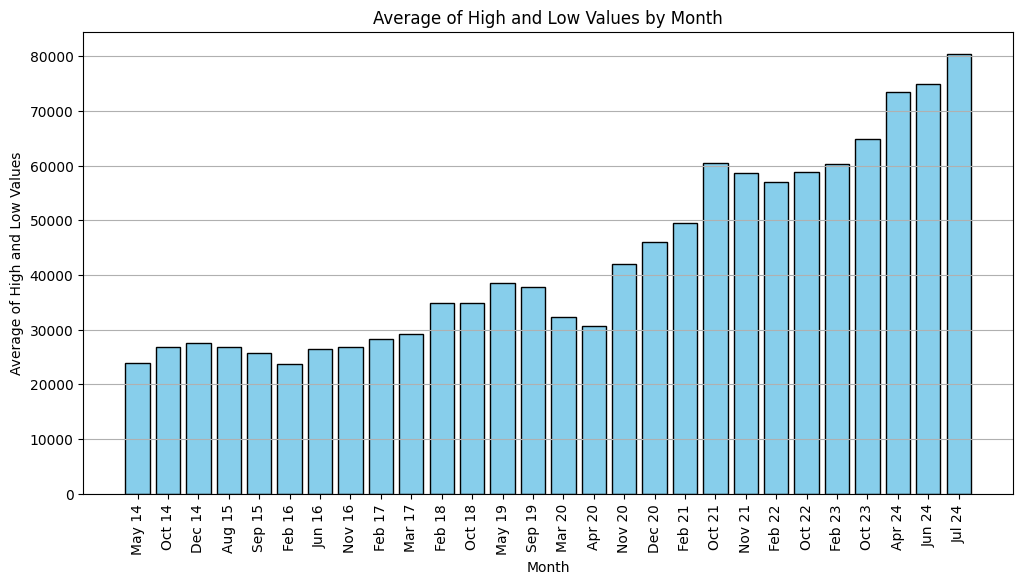

In [66]:
data_mon = pd.read_csv("E:/New folder/Sensex_Monthly.csv")
to_convert = [ 'High', 'Low']
for col in to_convert:
    if data_mon[col].dtype == 'object':  # Check if the column is of type object (usually strings)
        data_mon[col] = pd.to_numeric(data_mon[col].str.replace(',', ''), errors='coerce')
    else:
        data_mon[col] = pd.to_numeric(data_mon[col], errors='coerce')

# Calculate the average of 'High' and 'Low' values
data_mon['Average'] = (data_mon['High'] + data_mon['Low']) / 2

# Plot the bar graph
plt.figure(figsize=(12, 6))
plt.bar(data_mon['Month'], data_mon['Average'], color='skyblue', edgecolor='black')

plt.title('Average of High and Low Values by Month')
plt.xlabel('Month')
plt.ylabel('Average of High and Low Values')
plt.xticks(rotation=90)  # Rotate the x-axis labels for better readability
plt.grid(axis='y')

plt.show()


# Scatter Plot (Closing vs Return/log return%) 

         Date     Close  Return %  Log Return %
1  09-05-2014  22994.23  2.909903      2.868370
2  12-05-2014  23551.00  2.421347      2.392497
3  13-05-2014  23871.23  1.359730      1.350569
4  14-05-2014  23815.12 -0.235053     -0.235330
5  15-05-2014  23905.60  0.379927      0.379207


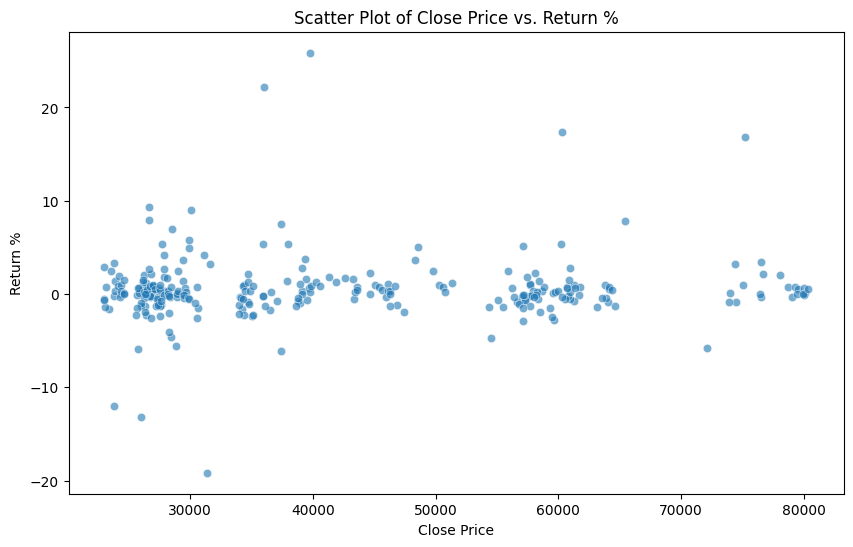

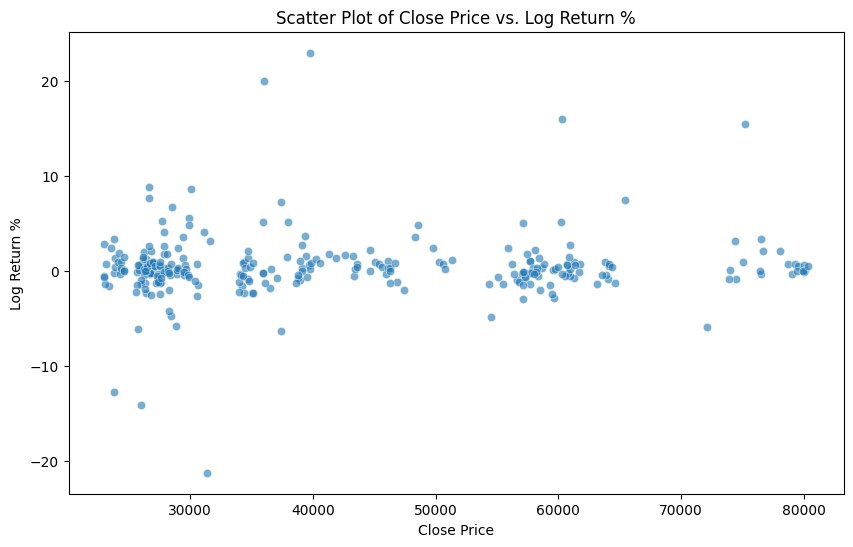

In [31]:
data['Return %'] = data['Close'].pct_change() * 100
data['Log Return %'] = np.log(data['Close'] / data['Close'].shift(1)) * 100
data = data.dropna(subset=['Return %', 'Log Return %'])


print(data[['Date', 'Close', 'Return %', 'Log Return %']].head())

# Create scatter plots
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Close', y='Return %', alpha=0.6)
plt.title('Scatter Plot of Close Price vs. Return %')
plt.xlabel('Close Price')
plt.ylabel('Return %')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Close', y='Log Return %', alpha=0.6)
plt.title('Scatter Plot of Close Price vs. Log Return %')
plt.xlabel('Close Price')
plt.ylabel('Log Return %')
plt.show()


# Data Analysis to show how Major Events effect the Market

In [46]:
sensex_df = pd.read_csv('E:/sel/bse_sensex.csv')
sensex_df['Date'] = pd.to_datetime(sensex_df['Date'], format='%d-%m-%Y')

# Convert numerical columns to float
for col in ['Open', 'High', 'Low', 'Close', 'Points Change']:
    sensex_df[col] = sensex_df[col].str.replace(',', '').astype(float)

# Set the 'Date' column as the index
sensex_df.set_index('Date', inplace=True)

# Function to analyze and visualize market reaction to an event
def analyze_event(event_name, event_date, window=10):
    # Convert event_date to datetime format
    event_date = pd.to_datetime(event_date)
    
    # Extract data around the event, handling the missing date issue by slicing within available dates
    event_data = sensex_df.iloc[(sensex_df.index >= event_date - pd.Timedelta(days=window)) & 
                               (sensex_df.index <= event_date + pd.Timedelta(days=window))]
    
    # Plot the data
    plt.figure(figsize=(10, 6))
    plt.plot(event_data.index, event_data['Close'], marker='o', label='Close')
    plt.axvline(x=event_date, color='red', linestyle='--', label='Event Date')
    plt.title(f"Market Reaction to {event_name}")
    plt.xlabel('Date')
    plt.ylabel('Sensex Close')
    plt.legend()
    
    # Format the x-axis for dates
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
    plt.xticks(rotation=45)
    
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Graphical Representation to show The market Closing change after the selected Events

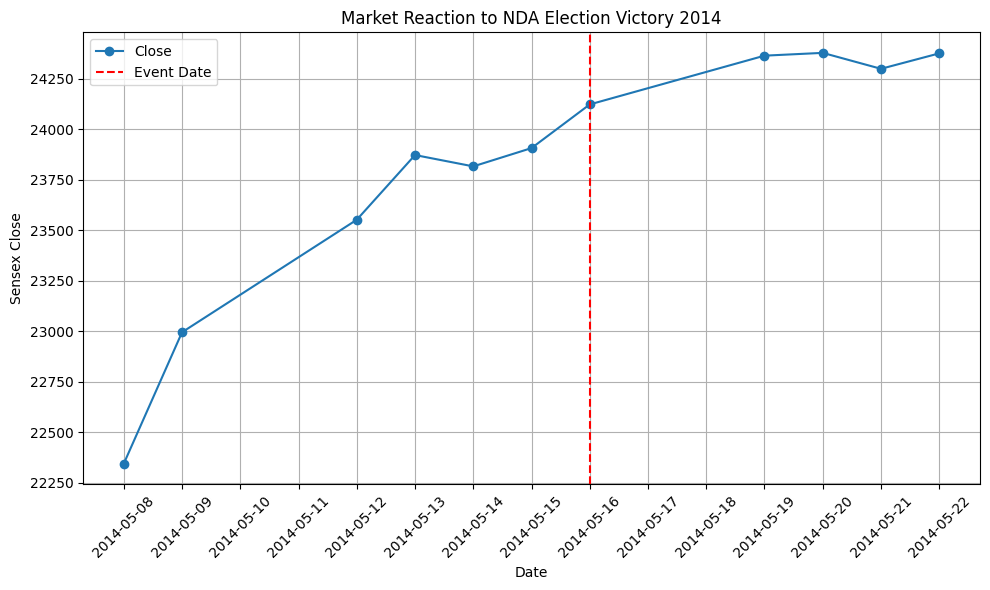

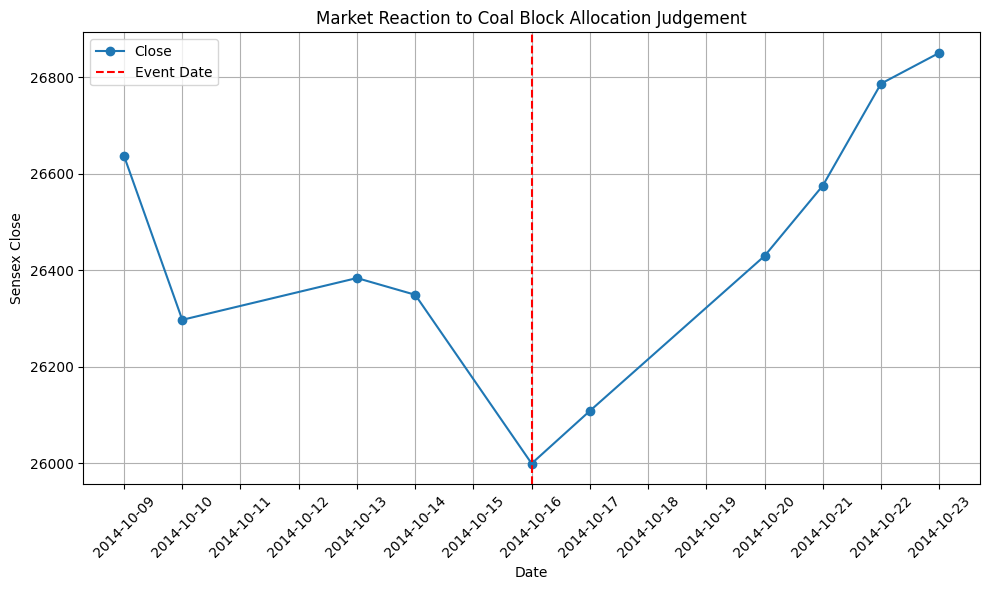

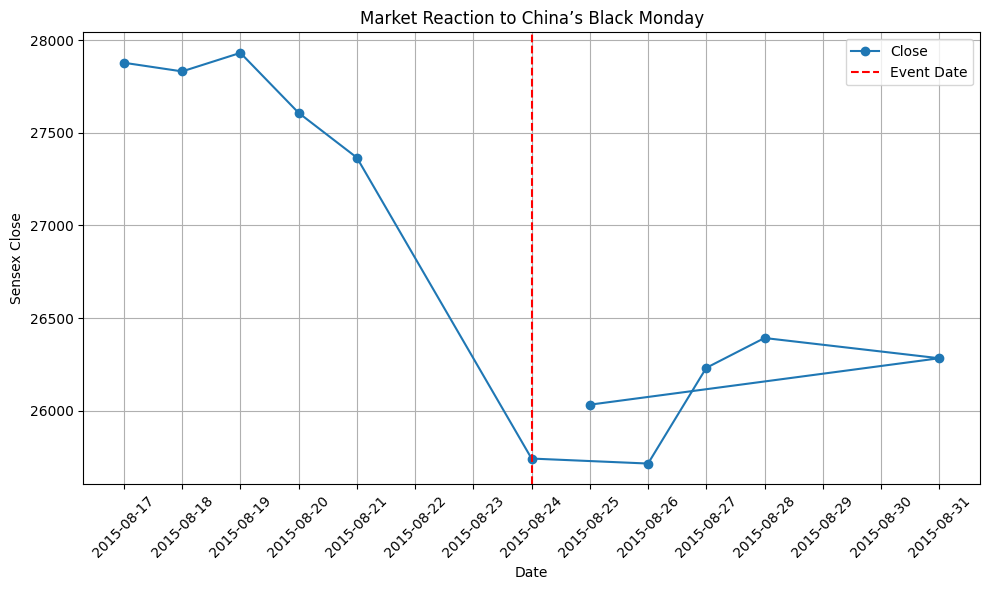

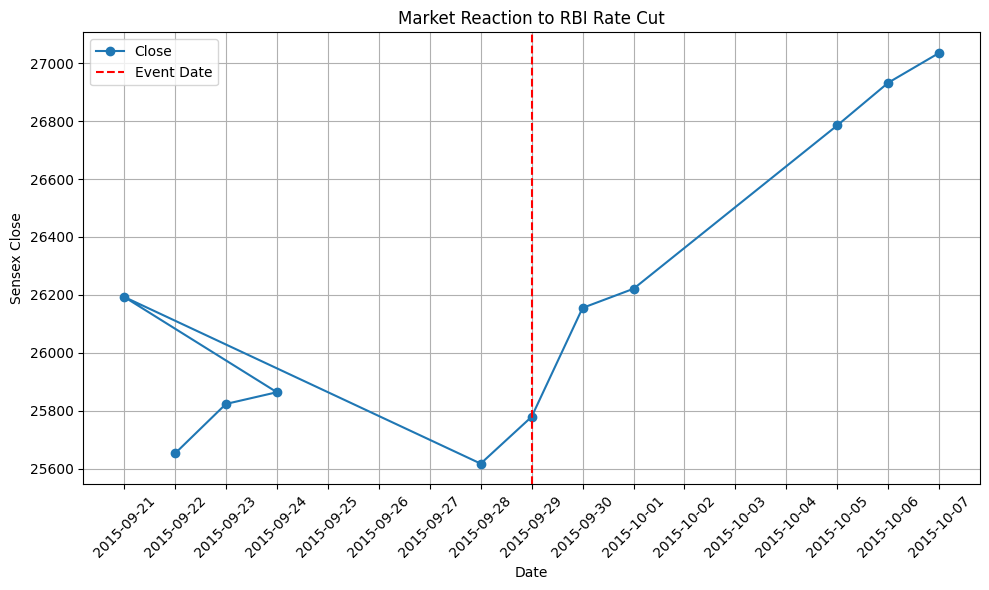

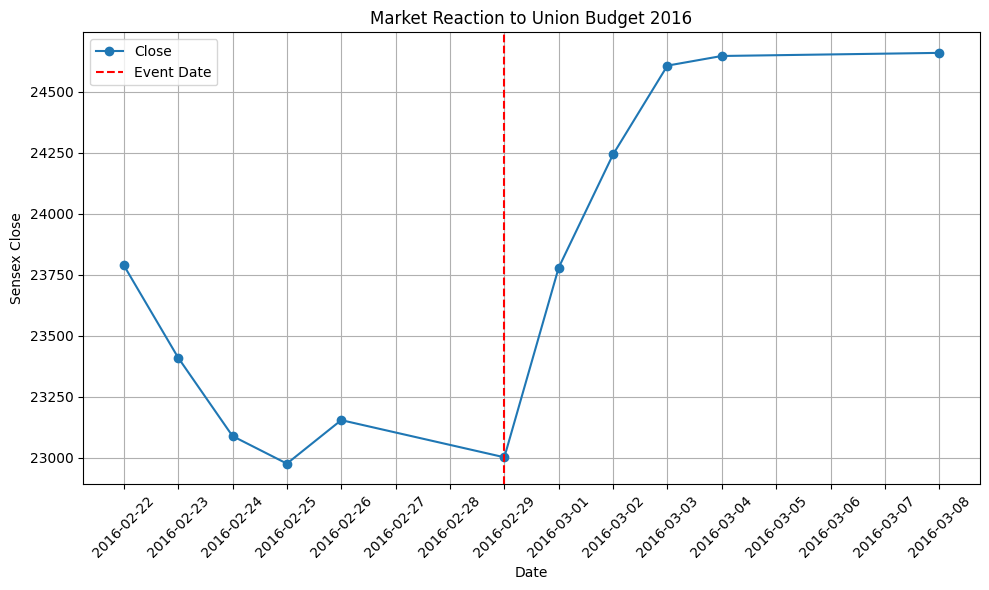

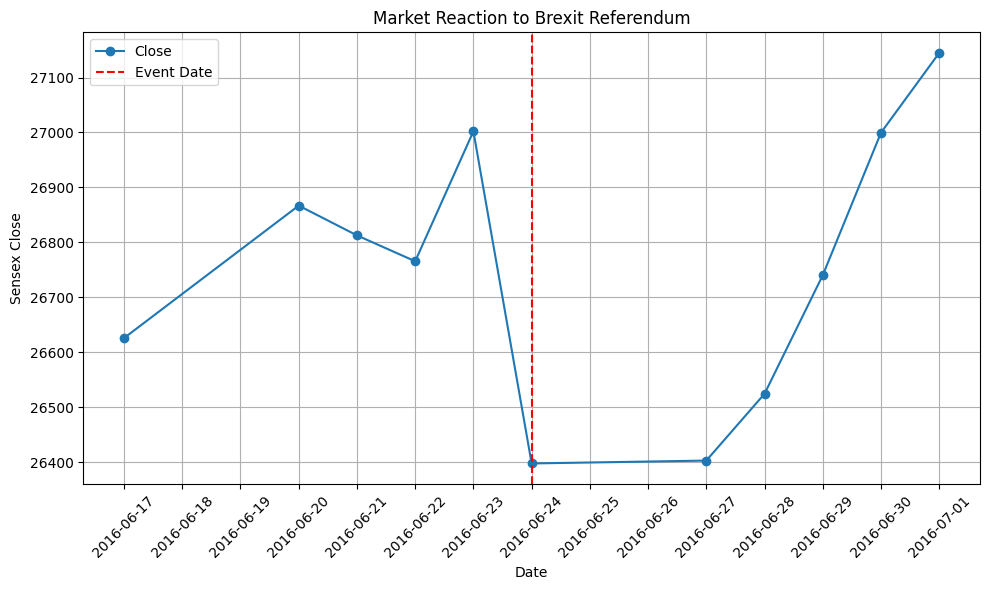

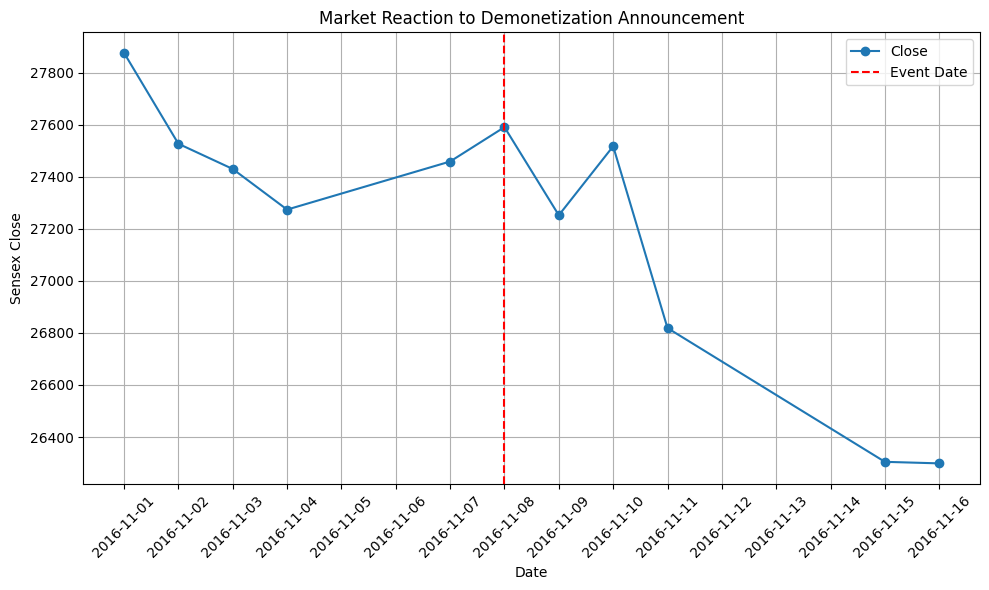

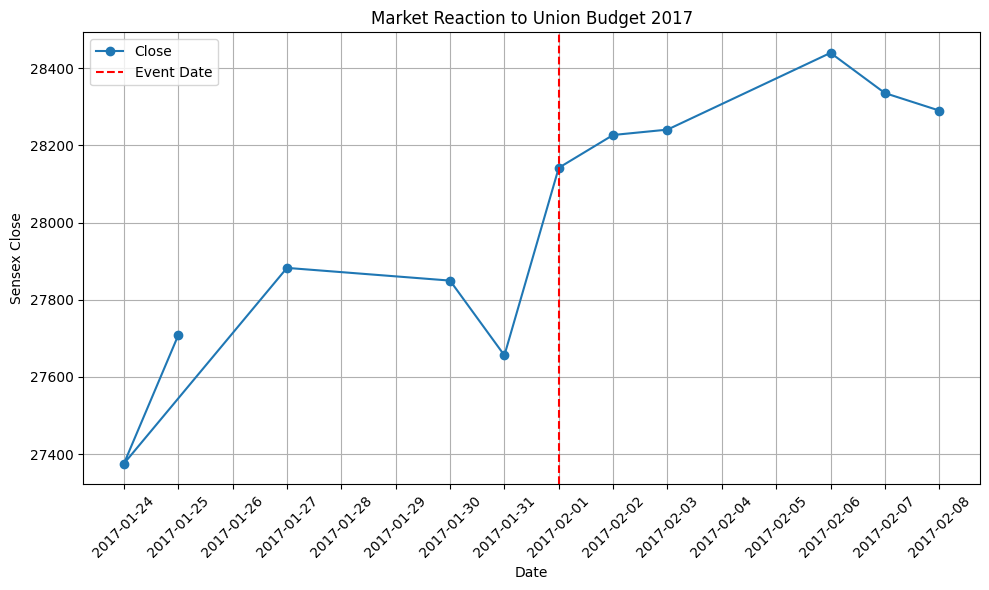

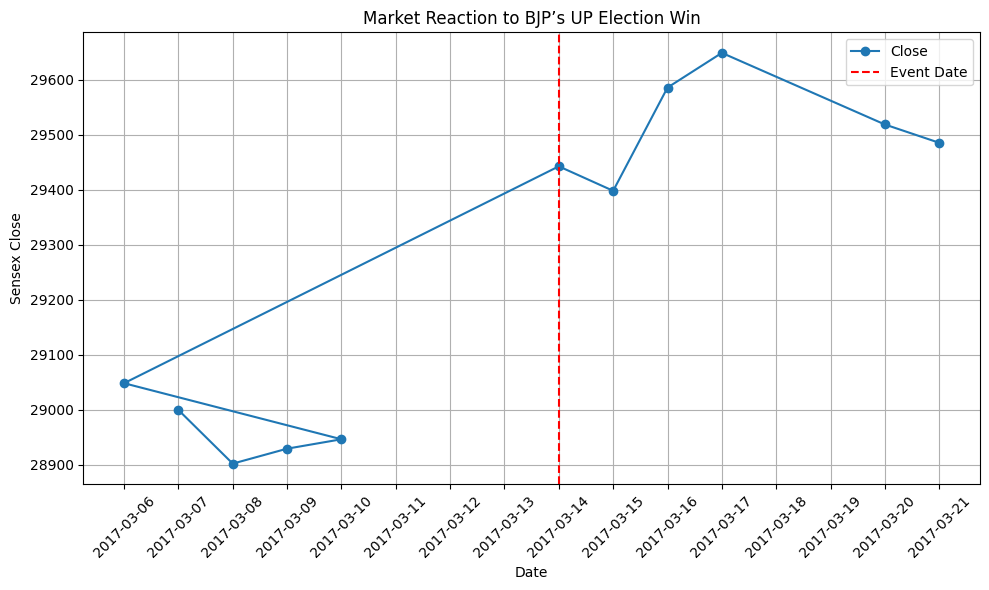

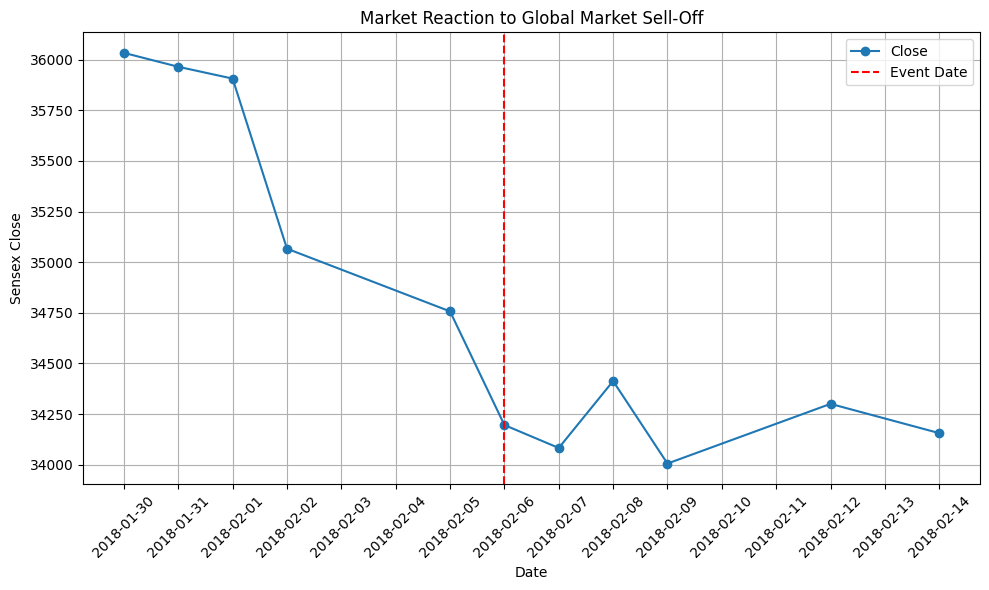

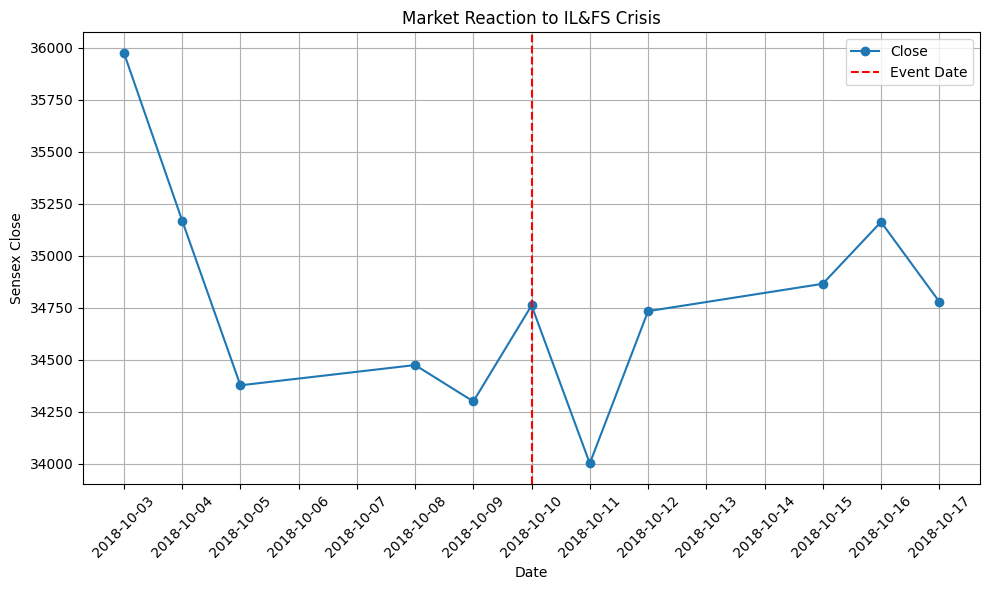

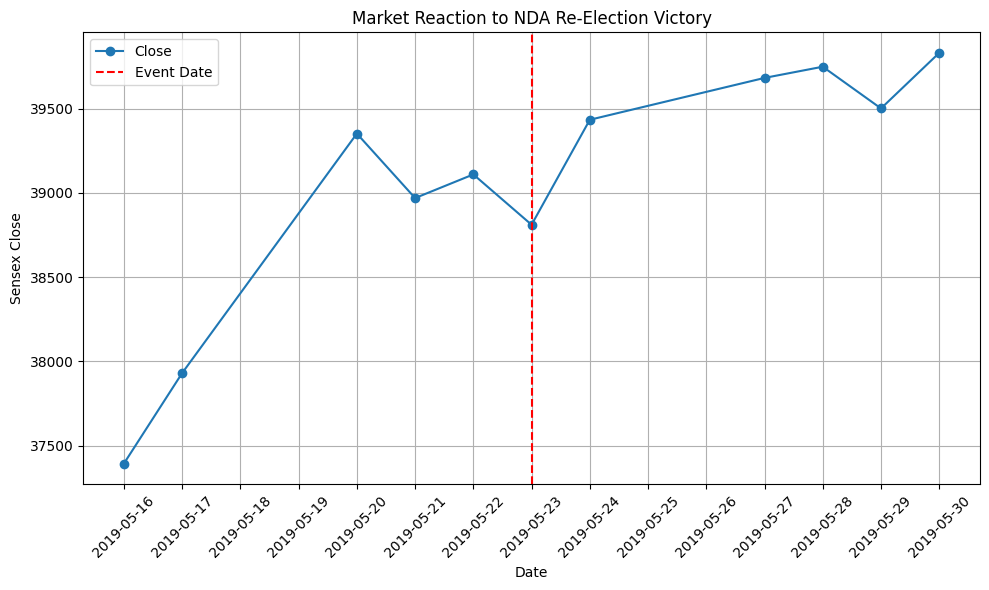

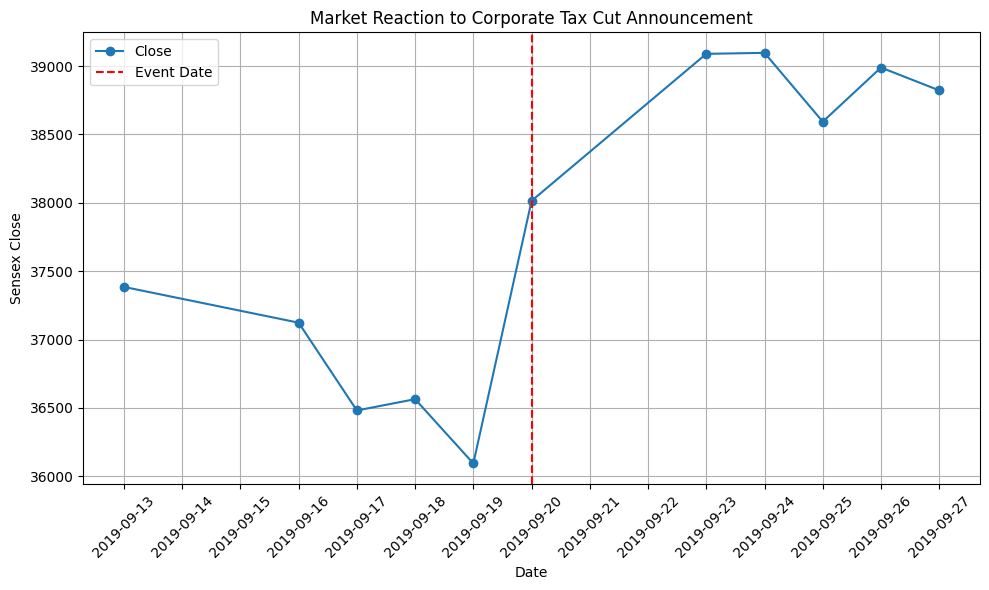

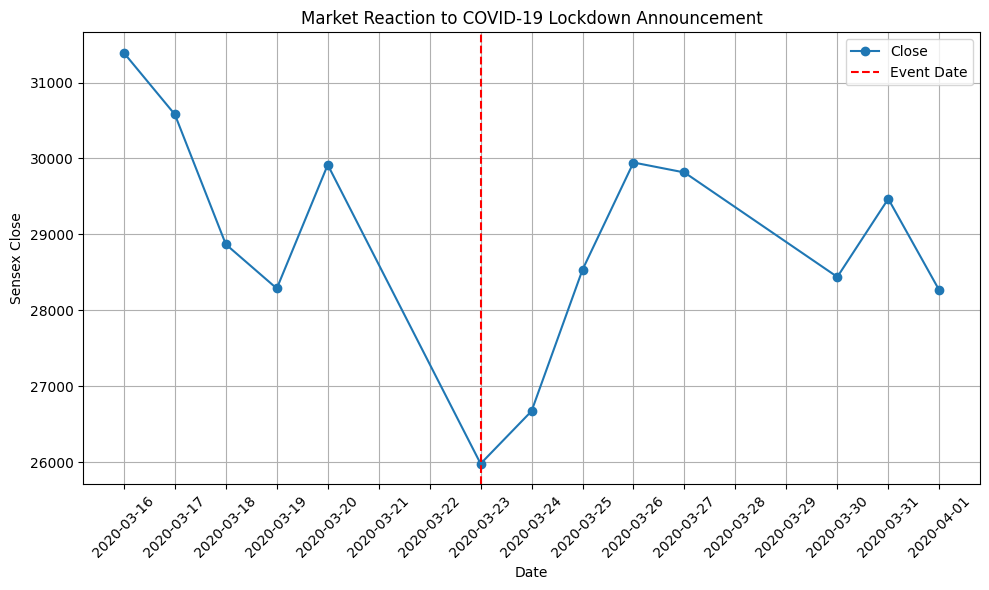

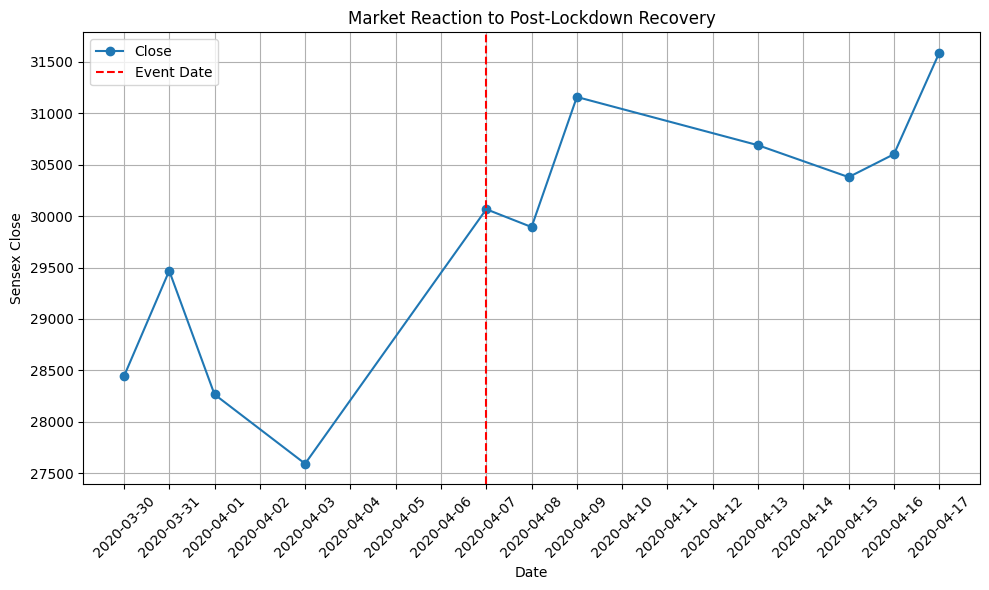

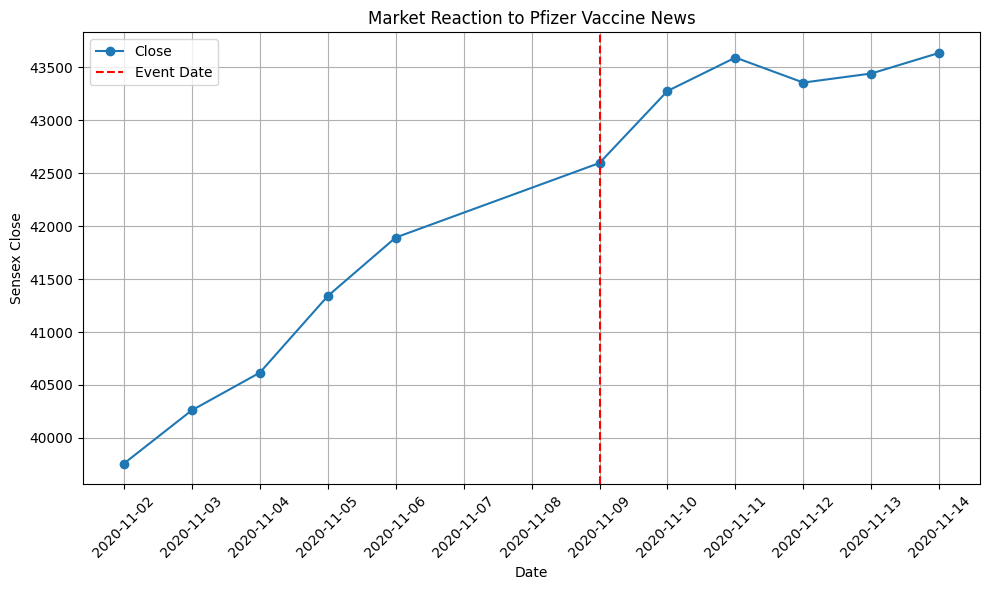

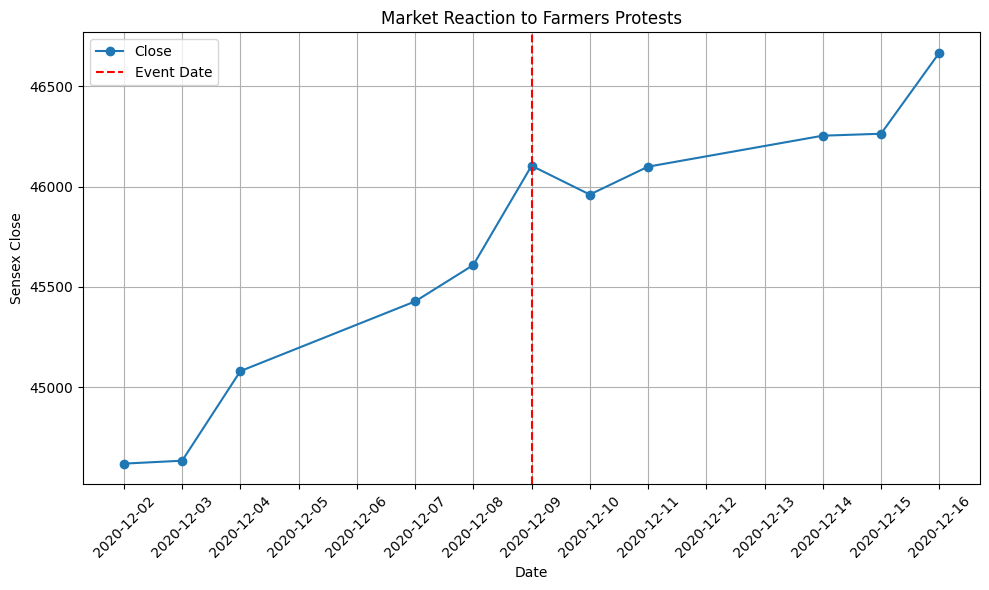

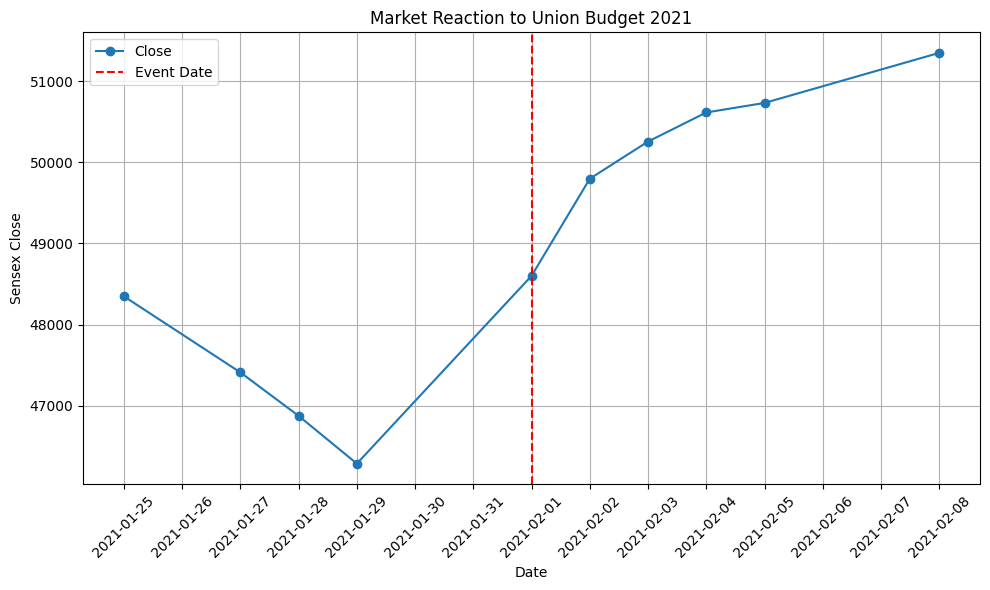

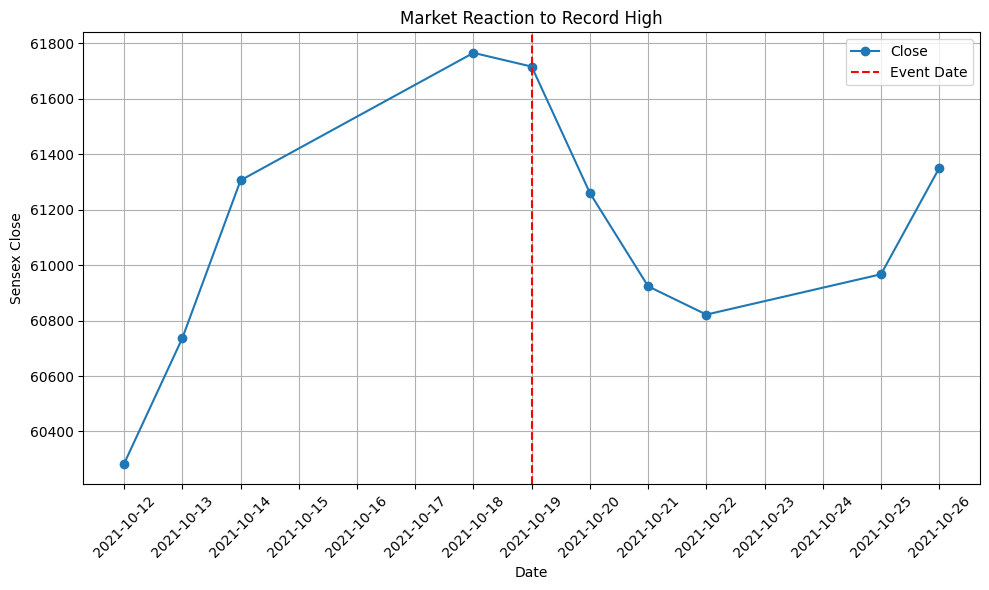

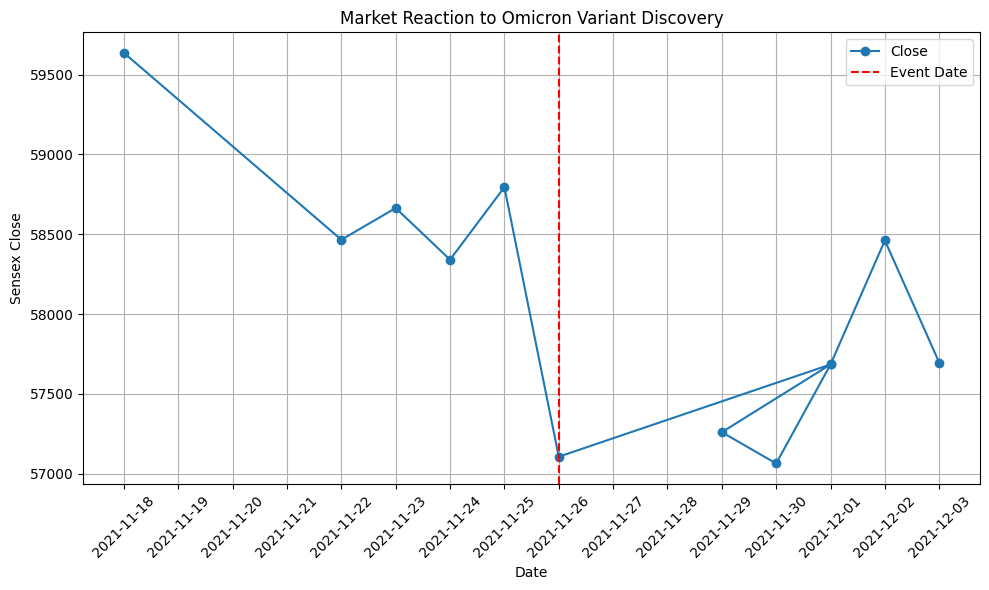

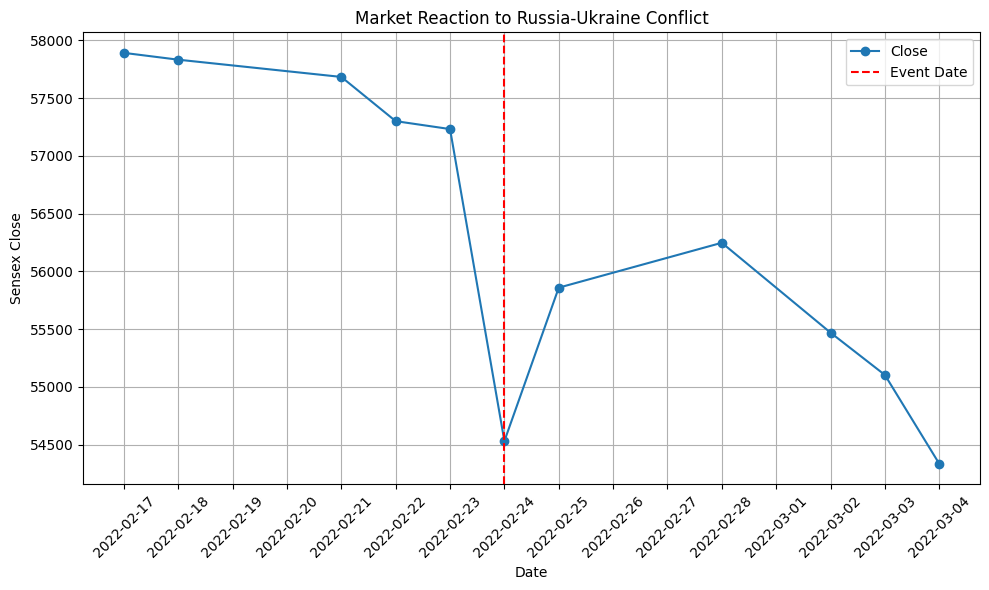

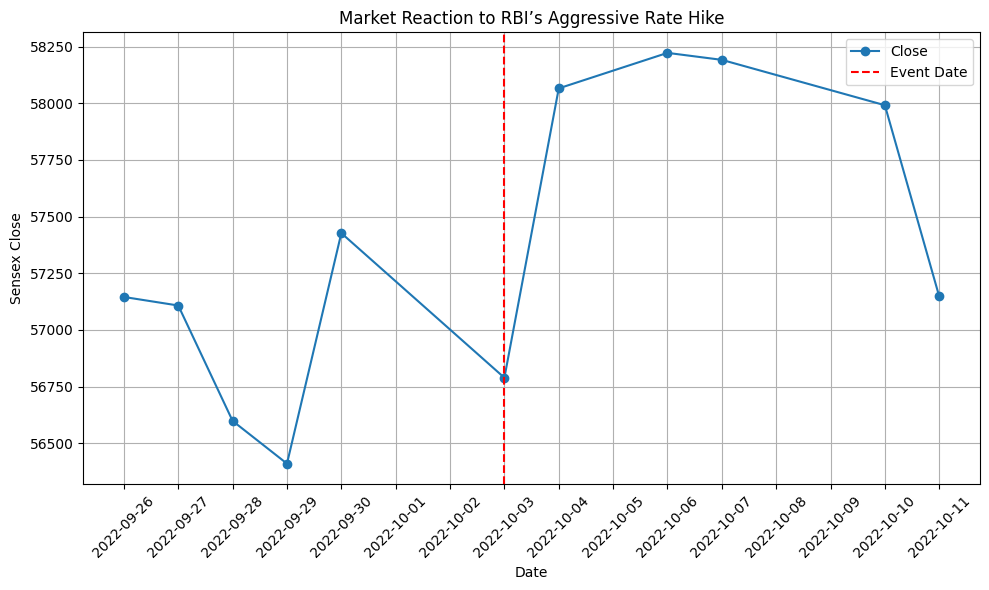

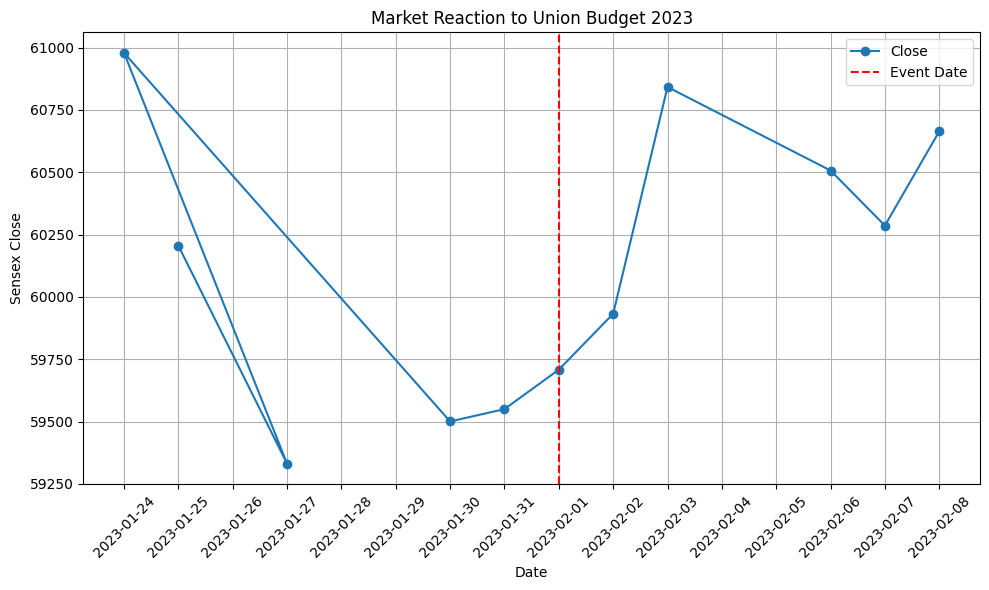

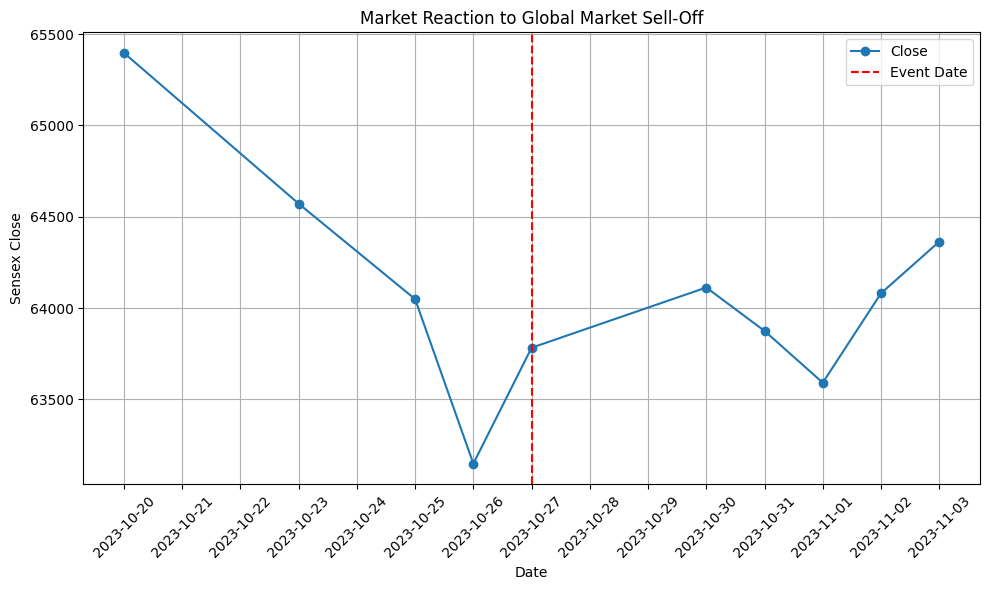

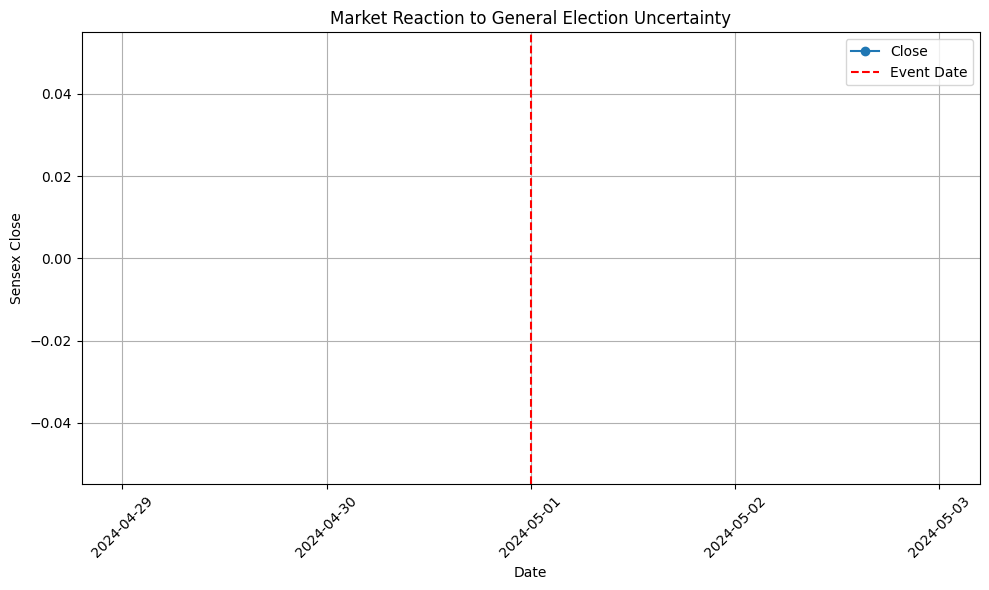

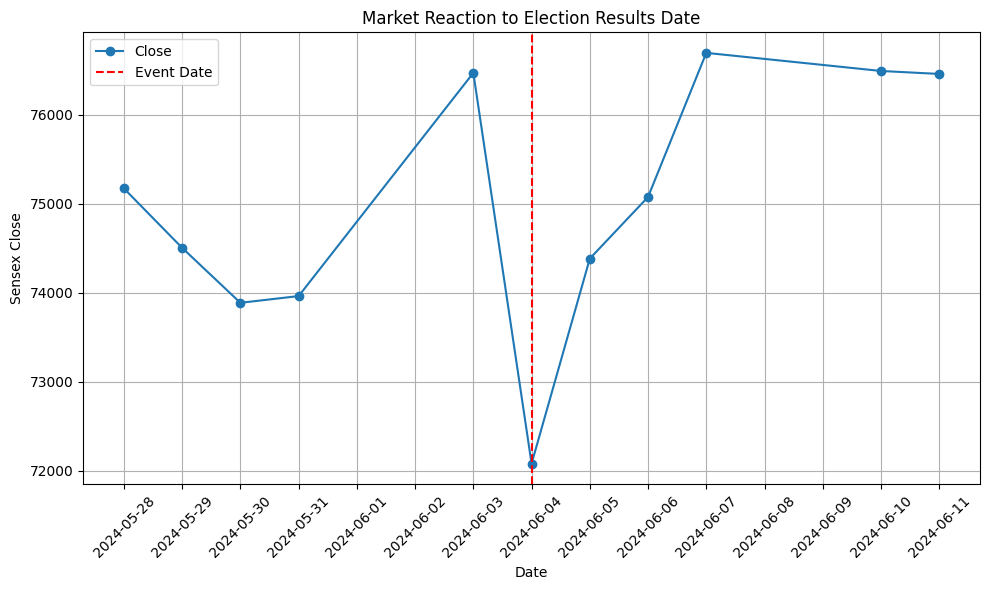

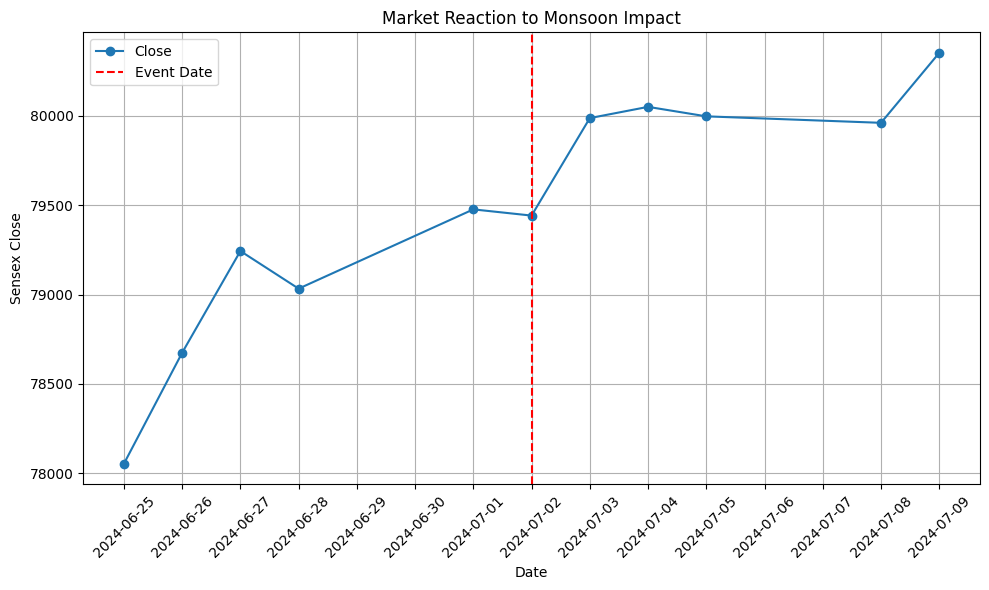

In [51]:
# NDA Election Victory on May 16, 2014
analyze_event("NDA Election Victory 2014", "2014-05-16")

# Coal Block Allocation Judgement on October 16, 2014
analyze_event("Coal Block Allocation Judgement", "2014-10-16")

# China’s Black Monday on August 24, 2015
analyze_event("China’s Black Monday", "2015-08-24")

# RBI Rate Cut on September 29, 2015
analyze_event("RBI Rate Cut", "2015-09-29")

# Union Budget 2016 on February 29, 2016
analyze_event("Union Budget 2016", "2016-02-29")

# Brexit Referendum on June 24, 2016
analyze_event("Brexit Referendum", "2016-06-24")

# Demonetization Announcement on November 8, 2016
analyze_event("Demonetization Announcement", "2016-11-08")

# Union Budget 2017 on February 1, 2017
analyze_event("Union Budget 2017",  "2017-02-01")

# BJP’s UP Election Win on March 14, 2017
analyze_event("BJP’s UP Election Win", "2017-03-14")

# Global Market Sell-Off on February 6, 2018
analyze_event("Global Market Sell-Off", "2018-02-06")

# IL&FS Crisis on October 10, 2018
analyze_event("IL&FS Crisis", "2018-10-10")

# NDA Re-Election Victory on May 23, 2019
analyze_event("NDA Re-Election Victory", "2019-05-23")

# Corporate Tax Cut Announcement on September 20, 2019
analyze_event("Corporate Tax Cut Announcement", "2019-09-20")

# COVID-19 Lockdown Announcement on March 23, 2020
analyze_event("COVID-19 Lockdown Announcement", "2020-03-23")

# Post-Lockdown Recovery on April 7, 2020
analyze_event("Post-Lockdown Recovery", "2020-04-07")

# Pfizer Vaccine News on November 9, 2020
analyze_event("Pfizer Vaccine News", "2020-11-09")

# Farmers Protests on December 9, 2020
analyze_event("Farmers Protests", "2020-12-09")

# Union Budget 2021 on February, 1 2021
analyze_event("Union Budget 2021", "2021-02-01")

# Record High on October 19, 2021 
analyze_event("Record High", "2021-10-19")

# Omicron Variant Discovery on November 26, 2021
analyze_event("Omicron Variant Discovery", "2021-11-26")

# Russia-Ukraine Conflict on February 24, 2022 
analyze_event("Russia-Ukraine Conflict", "2022-02-24")

# RBI’s Aggressive Rate Hike on October 3, 2022
analyze_event("RBI’s Aggressive Rate Hike", "2022-10-03")

# Union Budget 2023 on February 1, 2023
analyze_event("Union Budget 2023", "2023-02-01")

# Global Market Sell-Off on October 27, 2023
analyze_event("Global Market Sell-Off", "2023-10-27")

# Election Results Date on June 4, 2024
analyze_event("Election Results Date", "2024-06-04")

# Monsoon Impact July 2024
analyze_event("Monsoon Impact", "2024-07-02")
              